# Putting it together: General Linear Models for Decoding

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
from nilearn import datasets

hub_shared_data_dir = "/home/jovyan/shared/data/nilearn/"
os.environ["NILEARN_SHARED_DATA"] = hub_shared_data_dir
datasets.get_data_dirs()

['/home/jovyan/shared/data/nilearn/', '/home/jovyan/nilearn_data']

In this next example, we will re-use the code from the previous example to generate statistical maps for each visual category, one per run.

In [3]:
import numpy as np
import pandas as pd

from nilearn.datasets import fetch_haxby

haxby_dataset = fetch_haxby(subjects=(2,), data_dir=hub_shared_data_dir)

# set TR in seconds, following information in the original paper
t_r = 2.5

[fetch_haxby] Dataset found in /home/jovyan/shared/data/nilearn/haxby2001

In [4]:
# Load target information as string 
behavior = pd.read_csv(haxby_dataset.session_target[0], sep=" ")

unique_conditions = behavior["labels"].unique()
conditions = behavior["labels"].values

runs = behavior["chunks"].to_numpy()
unique_runs = behavior["chunks"].unique()

# events will take the form of a dictionary of Dataframes, one per run
events = {}

for run in unique_runs:

    # get the condition label per run
    conditions_run = conditions[runs == run]

    # get the number of scans per run, then the corresponding
    # vector of frame times
    n_scans = len(conditions_run)
    frame_times = t_r * np.arange(n_scans)

    # each event last the full TR
    duration = t_r * np.ones(n_scans)

    # Define the events object
    events_ = pd.DataFrame(
        {
            "onset": frame_times,
            "trial_type": conditions_run,
            "duration": duration,
        }
    )
    # remove the rest condition and insert into the dictionary
    # this will be our baseline in the GLM, so we don't want to model it as a condition
    events[run] = events_[events_.trial_type != "rest"]

In [5]:
from nilearn.image import index_img
from nilearn.glm.first_level import FirstLevelModel

# Instantiate the glm
glm = FirstLevelModel(
    t_r=t_r,
    mask_img=haxby_dataset.mask,
    high_pass=0.008,
    smoothing_fwhm=4,
)

summary_stats = []
conditions_label = []
run_label = []

for run in unique_runs:
    # grab the fmri data for that particular run
    fmri_run = index_img(haxby_dataset.func[0], runs == run)

    # fit the GLM
    glm.fit(fmri_run, events=events[run])

    # set up contrasts: one per condition
    conditions = events[run].trial_type.unique()
    for condition_ in conditions:
        summary_stats.append(glm.compute_contrast(condition_, output_type="all"))
        conditions_label.append(condition_)
        run_label.append(run)

We now have our statistical maps for each run in the `summary_stats` list.
We also have the visual category type in the `conditions_label` list,
and the run information in the `run_label` list.
Using all of these, we can perform a Support Vector Classifier (SVC) analysis using the `Decoder` object in Nilearn.

In [6]:
from sklearn.model_selection import LeaveOneGroupOut

from nilearn.decoding import Decoder

decoder = Decoder(
    estimator="svc",
    mask=haxby_dataset.mask,
    standardize=False,
    screening_percentile=5,
    cv=LeaveOneGroupOut(),
)
decoder.fit([stats["z_score"] for stats in summary_stats], conditions_label, groups=run_label)

# Return the corresponding mean prediction accuracy compared to chance
# for classifying one-vs-all items.

classification_accuracy = np.mean(list(decoder.cv_scores_.values()))
chance_level = 1.0 / len(np.unique(conditions))
print(
    f"Classification accuracy: {classification_accuracy:.4f} / "
    f"Chance level: {chance_level}"
)

Classification accuracy: 0.7589 / Chance level: 0.125


Working in a predictive framework provides us with different information than in a statistical learning framework, because we focus on the _generalizability_ of our findings (across runs, in this case).

```{note}
Generally, **statistical learning** focuses on identifying the relationship between variables (like BOLD activity and experimental conditions) within a dataset, while **machine learning** focuses on learning relationships that generalize across contexts. 
```

## A caveat : Interpreting decoder weight maps

Now we have a sense of how our decoder performs relative to chance. But what if we want to know what features it's using to achieve its performance ? 
One common strategy when working with a GLM is to look at the resulting statistical maps to understand which voxels have a relationship with our contrast of interest.
Let's assume that we want to use the same strategy here. 
First, we will run a [fixed-effects analysis](https://nilearn.github.io/dev/auto_examples/04_glm_first_level/plot_two_runs_model.html#sphx-glr-auto-examples-04-glm-first-level-plot-two-runs-model-py) on our `z_maps`, using all run-level `z_maps` for a given experimental condition. 
This will show which voxels are most involved in the fixed effects statistical map for a given experimental condition, Faces.

In [7]:
from itertools import compress

condition_mask = [condition_label == 'face' for condition_label in conditions_label]
face_summary_stats = list(compress(summary_stats, condition_mask))

In [8]:
from nilearn.glm.contrasts import compute_fixed_effects

contrast_imgs = [stats["effect_size"] for stats in face_summary_stats]
variance_imgs = [stats["effect_variance"] for stats in face_summary_stats]

fixed_fx_contrast, fixed_fx_variance, fixed_fx_stat, _ = compute_fixed_effects(
    contrast_imgs, variance_imgs, haxby_dataset.mask
)

Now we project the computed fixed-effect map to an FreeSurfer fsaverage5 surface for plotting.

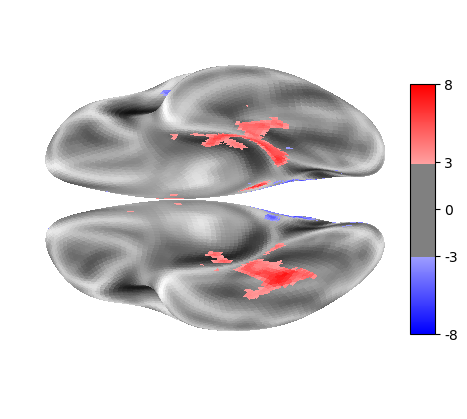

In [9]:
from nilearn.surface import SurfaceImage
from nilearn.plotting import plot_surf_stat_map, show
from nilearn.datasets import load_fsaverage, load_fsaverage_data

fsaverage5 = load_fsaverage()
fsaverage_data = load_fsaverage_data(data_type="sulcal")

surface_ffx = SurfaceImage.from_volume(
    mesh=fsaverage5["pial"],
    volume_img=fixed_fx_stat,
)

plot_surf_stat_map(
    surf_mesh=fsaverage5["inflated"],
    stat_map=surface_ffx,
    bg_map=fsaverage_data,
    hemi="both",
    view="ventral",
    threshold=3.0,
    cmap="bwr",
)
show()

OK, now that we have this map as a baseline, let's do the same plotting projection for the weight map for the "Face" condition.
We can see that the `decoder` object has a fitted `coef_img_` attribute for each experimental condition:

In [10]:
decoder.coef_img_

{'bottle': <nibabel.nifti1.Nifti1Image at 0x7efc8384c190>,
 'cat': <nibabel.nifti1.Nifti1Image at 0x7efc8384c3d0>,
 'chair': <nibabel.nifti1.Nifti1Image at 0x7efc8384c790>,
 'face': <nibabel.nifti1.Nifti1Image at 0x7efc8384ca90>,
 'house': <nibabel.nifti1.Nifti1Image at 0x7efc8384cb80>,
 'scissors': <nibabel.nifti1.Nifti1Image at 0x7efc8384c1c0>,
 'scrambledpix': <nibabel.nifti1.Nifti1Image at 0x7efc8384cd30>,
 'shoe': <nibabel.nifti1.Nifti1Image at 0x7efc8384cf40>}

So we access and plot it just as above:

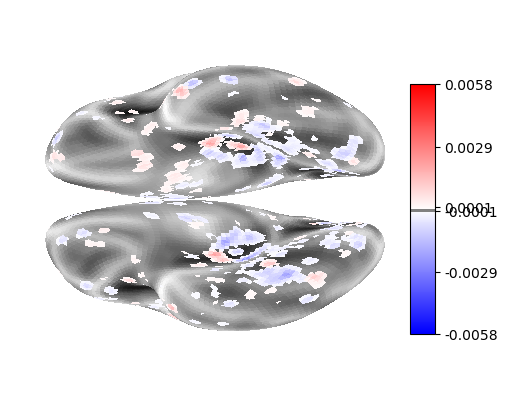

In [11]:
surface_coef = SurfaceImage.from_volume(
    mesh=fsaverage5["pial"],
    volume_img=decoder.coef_img_['face'],
)

plot_surf_stat_map(
    surf_mesh=fsaverage5["inflated"],
    stat_map=surface_coef,
    bg_map=fsaverage_data,
    hemi="both",
    view="ventral",
    threshold=0.0001,
    cmap="bwr",
)
show()

This map looks somewhat similar, but involves voxels from many other regions of the brain than just the Fusiform Face Area (FFA)!
How important are each of these individual voxels to our overall prediction performance ?
Unfortunately, it's hard to know just from these maps, as weight maps can be challenging to interpret directly {cite}`HAYNES2015257`.
Instead, we will want to use **Feature Importance** methods to evaluate how important a given voxel (or _feature_) is in making a prediction.
Feature importance is outside of the scope of this tutorial, but the library `highdimstat` (https://hidimstat.github.io) focuses on [exactly this problem](https://hidimstat.github.io/dev/concepts/general_concepts.html), and it has a [worked example using exactly this dataset](https://hidimstat.github.io/dev/generated/gallery/examples/plot_fmri_data_example.html) !

```{bibliography} references.bib
:style: unsrt
:filter: docname in docnames
```